## DV1597 - Assignment 1

#### Mauritz Almgren   manz24@student.bth.se <br> Anton Maksymchuk Netterström   anmy24@student.bth.se

This code contains all the solutions for Q1-Q11.

The questions regard a dataset from SMHI where we will need to handle various data cleaning tasks as well as aggregating the data in various ways. We will then need to do some data analyses on this dataset and visualize it.

## Question 1

Explain the data cleaning steps you consider for analyzing the provided dataset. You must motivate and describe why, how, and in which order you are going to apply the selected steps to the dataset. Note that you should consider applying your proposed data cleaning steps on the dataset to answer Q2-Q11 regardless of the questions’ order.

Answer

Steps

1. Observation of the dataset to find data errors and artifacts. <br>
The data was first explored to identify the potential issues with such as missing values and their
structure (Randomly distributed or in blocks).

2. Remove duplicates

3. Data type conversion<br>
The date column was converted to a datetime format

4. Ensure consistent time structure (resampling)

5. Flag extreme values and extreme changes ($\Delta T$ between hours) <br>
After doing some quick observation on the rawdata, we stumbled into some values that were over 38 degrees, in addition we found values where the change were over 9 degrees, which is physically most unlikey to occur. e.g

\begin{aligned}
\text{2010-07-11 16:00} &: 27.1^\circ\mathrm{C} \\
\text{2010-07-11 17:00} &: 36.0^\circ\mathrm{C} \\
\text{2010-07-11 18:00} &: 25.9^\circ\mathrm{C}
\end{aligned}

6. Replacing anomalies with missing values (NaN)

7. Imputation using interpolation
We used imputation to fill our NaN values with the help of interpolation. This means that we use linear interpolation based on time to predict what the temperature should be within 2 different timestamps where a NaN value is.

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('SMHI_Data.csv')


df_filled = df.copy()

# Drop duplicates
df_filled.drop_duplicates(subset = ["Datum", "Tid (UTC)"], inplace = True) # Remove duplicates timestamps

# Create datetime column and sort
df_filled["Datum_Tid"] = pd.to_datetime(df_filled["Datum"] + " " + df_filled["Tid (UTC)"])
df_filled = df_filled.dropna(subset=["Datum_Tid"])
df_filled = df_filled.sort_values("Datum_Tid").set_index("Datum_Tid")



# Resample missing timestamps 





# -------------------



# Flag unrealistic values ---
TEMP_MIN = -20
TEMP_MAX = 35

df_filled["flag_abs_temp"] = (
    (df_filled["Lufttemperatur"] < TEMP_MIN) |
    (df_filled["Lufttemperatur"] > TEMP_MAX)
)
# Flag unrealistic jumps ---





# --------------------------------

print(df_filled[df_filled["flag_abs_temp"]][["Lufttemperatur"]])
print(df_filled[df_filled["flag_jump"]][["Lufttemperatur"]])

# Putting values to NaN (values with flags) and interpolate 
df_filled.loc[df_filled["flag_abs_temp"], "Lufttemperatur"] = np.nan
df_filled.loc[df_filled["flag_jump"], "Lufttemperatur"] = np.nan

df_filled["Lufttemperatur"] = df_filled["Lufttemperatur"].interpolate(method="time", limit=3)

df_filled.to_csv("cleaned_data.csv", index=False)


                     Lufttemperatur
Datum_Tid                          
2010-07-11 13:00:00            38.8
2010-07-11 14:00:00            36.9
2010-07-11 17:00:00            36.0
2010-07-13 11:00:00            35.2
2010-12-21 21:00:00           -20.1
2014-07-07 16:00:00            35.4
2014-07-10 13:00:00            35.6
2014-07-24 12:00:00            37.9
2014-07-24 15:00:00            37.9
2014-07-25 12:00:00            37.0
2014-07-25 14:00:00            37.1
2014-07-25 15:00:00            36.4
2014-07-25 17:00:00            35.1
2014-07-26 15:00:00            35.8
2014-07-27 11:00:00            35.2
2014-07-28 11:00:00            36.9
2015-07-04 12:00:00            39.4
2015-07-05 10:00:00            36.9
2018-06-03 08:00:00            36.3
2018-06-03 18:00:00            37.0
2018-07-17 10:00:00            38.6
2018-07-17 13:00:00            37.5
2018-07-17 14:00:00            38.9
2018-07-17 15:00:00            37.0
2018-07-17 16:00:00            37.8
2018-07-24 12:00:00         

KeyError: 'flag_jump'

## Question 2

Does the dataset contain any missing values? If so, how many in both absolute terms and percentages? Reflect on the number of missing values. Do you regard it as much or not?

Answer: The dataset does indeed contain missing values. Following code shows that there is 131717 rows of data with 7756 of them having missing value. Which means that the ratio of missing value is ~6%. This proportion is relatively low and
is considered managable for analysis. On important note, after observation on the CSV file itself, we can clearly see that the NaN values appears to be randomaly distributed rather than occuring in blocks, which further helps using different impution methods.



In [ ]:
x = df['Lufttemperatur'].isna().sum()

y = len(df['Lufttemperatur'])

percentage = (x/y).round(4)

print(f"Total rows: {y}")
print(f"Total rows with NaN: {x}")
print(f"NaN ratio: {percentage * 100}%")

Total rows: 131717
Total rows with NaN: 7756
NaN ratio: 5.89%


## Question 3

Which strategy was used for handling the missing values? Motivate why you consider the selected strategy the most suitable for this task.

Answer

We used imputation to fill our NaN values with the help of interpolation to predict what the temperature should be. We used this method over dropping the NaN values as we would have lost timestamps which we think isn't good practice in this scenario. Predicting temperature is an easier way to find "realistic" values to fill our dataset with.

## Question 4

Calculate the following statistics for the air temperature values in the dataset:
* minimum value
* maximum value
* sample mean
* Q1/Q2/Q3 quartiles
* sample standard deviation
* 95% confidence interval of the mean

Answer

In [ ]:
min_value = df_filled['Lufttemperatur'].min()
max_value = df_filled['Lufttemperatur'].max()

print(f'Minimum value of temperature: {min_value}')
print(f'Maximum value of temperature: {max_value}')
print(f'Sample mean: {df_filled["Lufttemperatur"].mean()}')
print(f'Q1: {df_filled["Lufttemperatur"].quantile(0.25)}')
print(f'Q2 (median): {df_filled["Lufttemperatur"].quantile(0.5)}')
print(f'Q3: {df_filled["Lufttemperatur"].quantile(0.75)}')
print(f'Standard deviation: {df_filled["Lufttemperatur"].std()}')
print(f'95% CI: [{df_filled["Lufttemperatur"].mean() - 1.96 * df_filled["Lufttemperatur"].std() / np.sqrt(len(df_filled))}, {df_filled["Lufttemperatur"].mean() + 1.96 * df_filled["Lufttemperatur"].std() / np.sqrt(len(df_filled))}]')

Minimum value of temperature: -20.1
Maximum value of temperature: 39.4
Sample mean: 9.46059613548833
Q1: 4.1
Q2 (median): 9.1
Q3: 15.3
Standard deviation: 6.974376145133005
95% CI: [9.422576390145911, 9.49861588083075]


## Question 5

Plot all available air temperature data as a line plot with dates on the x-axis.

<Axes: xlabel='Datum'>

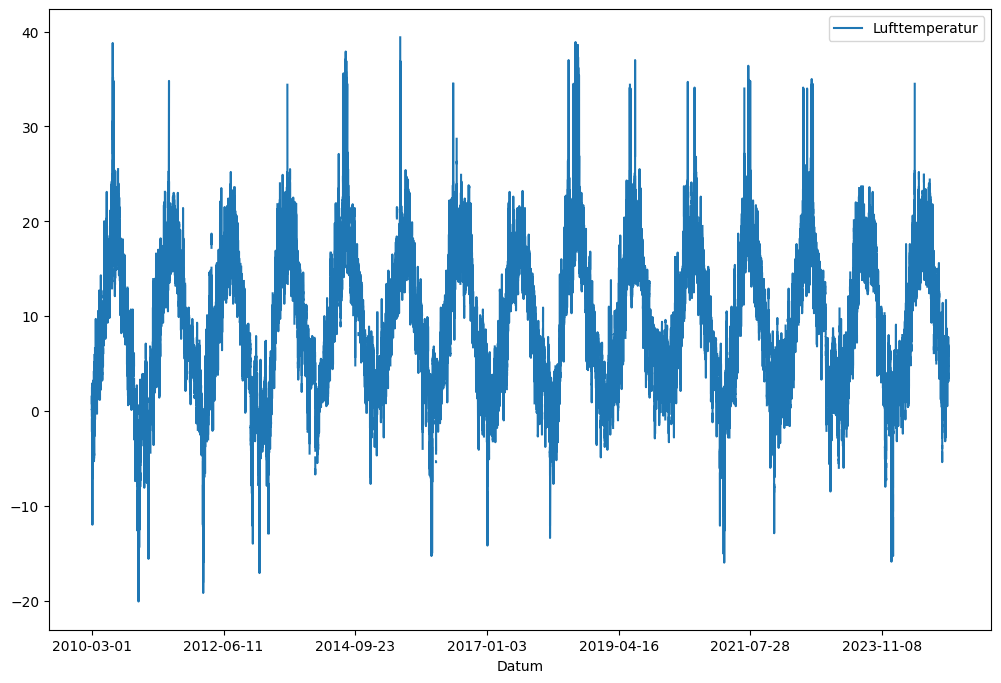

In [127]:
plt.style.use("default")
df_filled.plot.line(figsize = (12.16, 8.06), x = "Datum", y = "Lufttemperatur")


## Question 6

Rank the overall temperature per month, sort from the coldest to the
warmest. List the top ten (10) coldest months in the dataset. Format the
output as: YEAR/Month: temp, e.g.“2010/January: -5.0

In [103]:
df_rank = df_filled.copy()

df_rank["Datum"] = pd.to_datetime(df_rank["Datum"])

df_rank["Year"] = df_rank["Datum"].dt.year
df_rank["Month"] = df_rank["Datum"].dt.month
df_rank["Month_name"] = df_rank["Datum"].dt.month_name()

monthly_temp = (
    df_rank.groupby(["Year", "Month", "Month_name"])["Lufttemperatur"].mean()
)

monthly_temp = monthly_temp.sort_values()

coldest_10 = monthly_temp.head(10)

for (year, month_num, month_name), temp in coldest_10.items():
    print(f"{year}/{month_name}: {temp:.1f}")

2010/December: -3.8
2011/February: -1.5
2012/February: -1.4
2021/February: -1.0
2016/January: -1.0
2018/February: -0.9
2013/March: -0.8
2013/January: -0.6
2012/December: -0.6
2013/February: -0.4


## Question 7

Which distribution is suitable to consider to fit the air temperature data?
How well does the data follow that distribution given some measure, e.g., p-value?

Answer

Since the air temperature is influenced by seasons during the years, resulting a bimodal distribution with each peak for summer and winter (This is seen by plotting the data with hisogram). Therefor, a single normal distribution is not fully suitable to model the data. This helps us to identify the methods that is suitable for prediction, for example we cant really use the basic linear regression without using periodic functions. Notice that there is two histograms below where the blue represents the data before cleaning while orange represents the data after cleaning. Comparing these two helps assess whether the overall structure of the data distribution has been preserved during the cleaning process.

To support the argument for the distribution being bimodal, we used Shapiro-Wilk test to perform a two-sided hypothesis test with following statement <br><br>
$H_0$ : The dataset follows a normal distribution <br>
$H_1$ : The dataset do not follow a normal distribution

The resulting p-value (see below) was lower than 0.05, leading to rejection of null hypothesis ($H_0$). Which indicates that the following dataset does not follow a normal distribution.

p-value: 1.362815928122455e-23
Reject null hypothesis of nornamlity


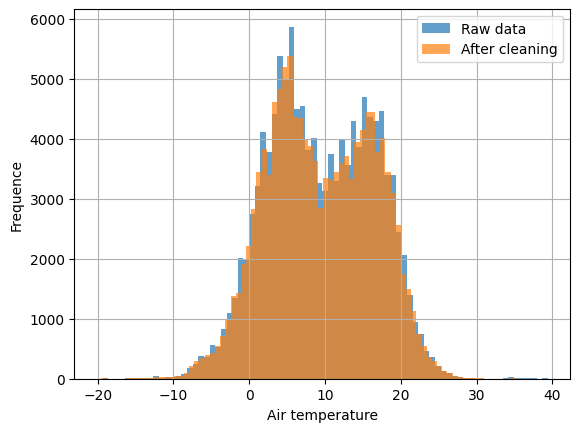

In [ ]:
from scipy.stats import shapiro

sample = df_filled["Lufttemperatur"].sample(5000)
stat, p = shapiro(sample)

print("p-value:", p)
print("Reject null hypothesis of nornamlity" if p < 0.05 else "Fail to reject null hypothesis of normality")


# Plotting of data
df["Lufttemperatur"].hist(bins = 80, alpha = 0.7, label = "Raw data")
df_filled["Lufttemperatur"].hist(bins = 80, alpha = 0.7, label = "After cleaning")
plt.legend()
plt.xlabel("Air temperature")
plt.ylabel("Frequence")
plt.show()


## Question 8

Do you regard any of the air temperature measures in the dataset to
be extreme values/outliers? If so, how many values? Motivate why you
consider these values as anomalies.

Answer

Yes, we noticed several extreme values when it comes to air temperature itself. Knowing that dataset contains data from Karlskrona, we can use historic knowledge knowing that temperature $ \gt 35^\circ\mathrm{C}$ **rarely** occurs. By thus, we decided to implement two limits Max_temp = 35 and Min_temp = -20. 
<br><br>
On another note, as mentioned in $Q1$. Values showing a change greater than 9 between measurements were considered as unrealistic. This statement can be supported by using normal distribution for $\delta T$, which appears approximately normally distributed (as shown below)
<br>
Applying a z-score approach $ |z| \gt 3$ results in a threshold of approximately 2.2 degrees, indicating that changes larger than this is **statistically uncommon**. However, such changes are still physically realistic and occur often. Therefore, this implies that changes over $ \approx 9 $ is both **extremely statistically unlikely** and **physically unrealistic** in Sweden.


Values above 35°C: 48
Values below -20°C: 1


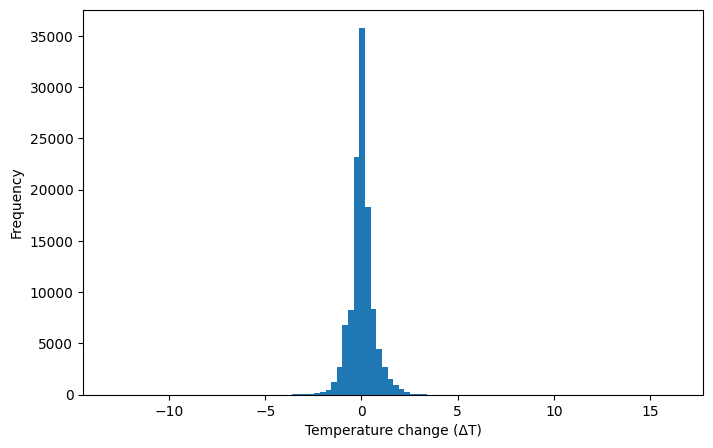

In [102]:
count_above = (df["Lufttemperatur"] > TEMP_MAX).sum()
count_below = (df["Lufttemperatur"] < TEMP_MIN).sum()

print("Values above 35°C:", count_above)
print("Values below -20°C:", count_below)


df["dT"] = df["Lufttemperatur"].diff()


plt.figure(figsize=(8,5))
plt.hist(df["dT"].dropna(), bins=100)
plt.xlabel("Temperature change (ΔT)")
plt.ylabel("Frequency")
plt.show()

## Question 9

Calculate the mean temperature for each day in the year 2024 and then
plot those means using a line plot with dates on the x-axis.

<Axes: xlabel='Datum'>

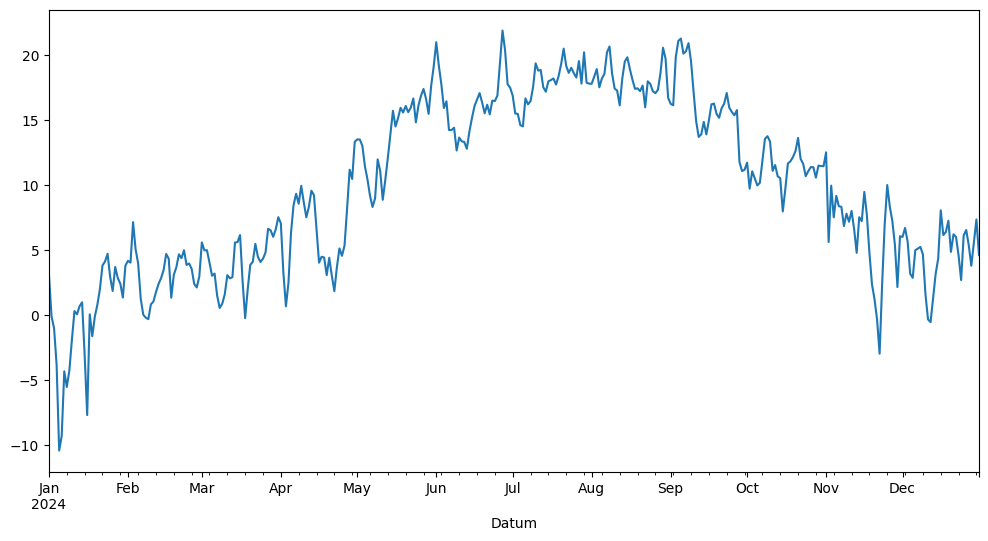

In [79]:

df_filled["Datum"] = pd.to_datetime(df_filled["Datum"])

df_filled["Year"] = df_filled["Datum"].dt.year
df_filled["Month"] = df_filled["Datum"].dt.month
df_filled["Month_name"] = df_filled["Datum"].dt.month_name()

df_filled = df_filled[df_filled["Year"] == 2024]

daily_mean = df_filled.groupby("Datum")["Lufttemperatur"].mean()

daily_mean.plot.line(figsize = (12,6), x = "Datum", y = "Lufttemperatur")


## Question 10


Rank the overall temperature per two (2) consecutive months, starting with the warmest 2-month period first.

For a given year $Y_i$ and month $M_j$, compute the average temperature as:

$$
\frac{Y_i M_j + Y_i M_{j+1}}{2}
$$

including the transition between years:

$$
\frac{Y_i M_{12} + Y_{i+1} M_1}{2}
$$

This results in a sequence such as:

$$
\frac{Y_1 M_1 + Y_1 M_2}{2},\
\frac{Y_1 M_2 + Y_1 M_3}{2},\
\ldots,\
\frac{Y_1 M_{11} + Y_1 M_{12}}{2},\
\frac{Y_1 M_{12} + Y_2 M_1}{2},\
\ldots
$$

Sort all computed 2-month averages in descending order and list the ten (10) warmest 2-month periods in the dataset.

## Question 11

Calculate the 95% confidence intervals (CI) for the mean of each daily
average in Q9 and add it to the line plot that shows the mean values of
each day of the year 2024. You can, for example, solve this by plotting the
upper and lower bounds as lines above and below the mean line in your
plot. Another more nicely looking solution is to visualize the CI as shades
around the mean line in your plot